# Project 3
**Alexander Greus, Spencer Smith**

## Question 1 - Method
We chose to use K-Means. We chose this firstly because it is provided by the sci-kit learn package which we are familiar with and have used for previous projects. It is also relatively simple to understand and interpret, as well it has been discussed in class lectures. The datasets are also just 2-3 dimensional floating point values which is in the wheelhouse of k-means.

## Question 2 - Measures
For our goodness/performance measure we chose to use silhouette score. For each point this compares the average distance to other points in its cluster to those in the nearest neighbor cluster. Its domain is between -1 to +1 where values closer to +1 indicate that a point is well fitted to its current cluster and not to neighboring clusters. Closer to 0 signifies that the point is sort of ambivalent / near a boundary between potentially 2 valid clusters. Finally, -1 signifies that a point is not well fitted to it current cluster. The average of each point is the overall silhouette score. We chose this since it doesn't require any labels or otherwise known ground truth, and its relatively simple, as well it is also provided by the scikit package. We also use the silhouette to try to choose the best k out of a range of possible k clusters.

## Question 3 - Graphics
Since this is about clustering, our primary method of visualization is simply plotting our data along with coloring based on assigned cluster. This is visually intuitive and understandable. We will also plot our silhouette scores against the ranges we tried.

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
import os

os.makedirs("cluster_outputs", exist_ok=True)

def find_best_k(data, k_range=range(2, 9)):
    scores = {}
    for k in k_range:
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = km.fit_predict(data)
        scores[k] = silhouette_score(data, labels)
    best_k = max(scores, key=scores.get)
    return best_k, scores


def do_kmeans_and_save_results(df, dataset_name, k):
    data = df.values
    
    results = {}
    for n in [k - 1, k, k + 1]:
        if n < 2:
            continue
        km = KMeans(n_clusters=n, random_state=42, n_init=10)
        labels = km.fit_predict(data)
        score = silhouette_score(data, labels)
        results[n] = {"labels": labels, "score": score, "model": km}

        for cluster_id in range(n):
            cluster_df = df[labels == cluster_id]
            fname = f"cluster_outputs/{dataset_name}_k{n}_cluster{cluster_id}.csv"
            cluster_df.to_csv(fname, index=False)

    return results


def plot_clusters(df, labels, title):
    plt.figure(figsize=(6, 5))
    scatter = plt.scatter(df["x"], df["y"], c=labels, cmap="tab10", s=20)
    plt.title(title)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.colorbar(scatter, label="Cluster")
    plt.tight_layout()
    plt.show()

def plot_clusters_3d(df, labels, title):
    """Scatter plot for 3D datasets."""
    fig = plt.figure(figsize=(6, 5))
    ax = fig.add_subplot(projection='3d')
    scatter = ax.scatter(
	    df["x"],
	    df["y"],
	    df["z"],
	    c=labels,
	    cmap="tab10",
	    s=20,
	    vmin=0,
	    vmax=10
	)
    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")
    plt.colorbar(scatter, label="Cluster", pad=.1)
    plt.tight_layout()
    plt.savefig(f'plots/{title.split("(")[0].replace(" ", "").replace("–", "_").replace("=", "")}.png', transparent=True)

def plot_silhouette_curve(scores_dict, dataset_name):
    ks = sorted(scores_dict.keys())
    sils = [scores_dict[k] for k in ks]
    plt.figure(figsize=(5, 3))
    plt.plot(ks, sils, marker="o")
    plt.title(f"{dataset_name} – Silhouette Score vs k")
    plt.xlabel("k")
    plt.ylabel("Silhouette Score")
    plt.xticks(ks)
    plt.tight_layout()
    plt.show()

## Dataset 1

In [21]:
df1 = pd.read_csv("Dataset 1.csv", header=None, names=["x", "y"])

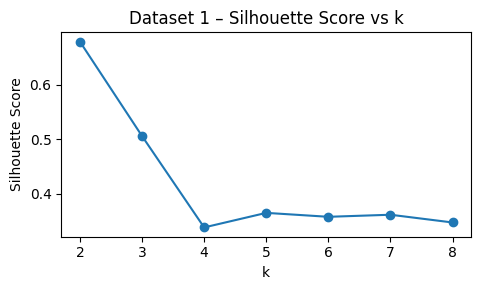

In [22]:
# Find best k
best_k1, scores1 = find_best_k(df1.values)
plot_silhouette_curve(scores1, "Dataset 1")

  k=2  |  Silhouette Score: 0.6791


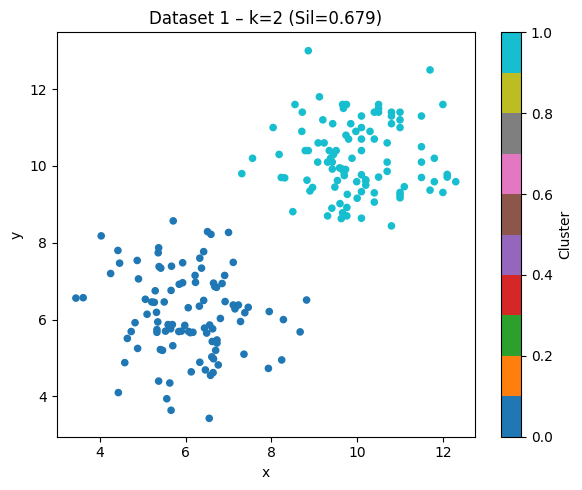

  k=3  |  Silhouette Score: 0.5058


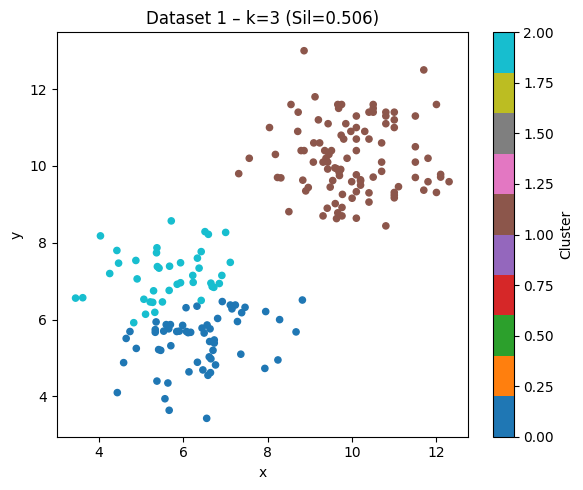

In [23]:
results1 = do_kmeans_and_save_results(df1, "Dataset1", best_k1)

for k, res in results1.items():
    print(f"  k={k}  |  Silhouette Score: {res['score']:.4f}")
    plot_clusters(df1, res["labels"], f"Dataset 1 – k={k} (Sil={res['score']:.3f})")

### Analysis
This dataset is a list of 2D points. Just from looking at the raw data its pretty obvious from the getgo that there ought to be 2 clusters. They are also relatively similarly sized and 'convex' so we can predict that k-means will be quite good at correctly identifying the 2 clusters. And indeed it was, using silhouette score we maximized to a score of 0.6791 at k=2 clusters. This is a pretty good score, being relatively close to +1. We can see that at k=3 we already visually see some arbitrary clustering as well as a steep drop in silhouette score, now at 0.5058. So it seems obvious we only have 2 clusters and our method was able to discern that fairly effectively. Of course this was a problem very kind to both k-means and silhouette score so its not unsurprising.

## Dataset 2

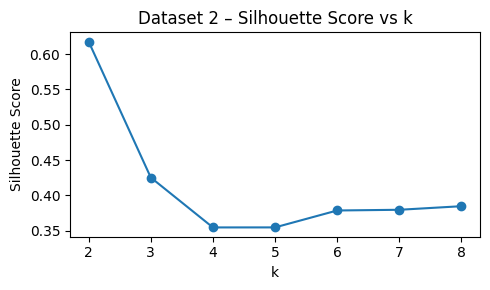

  k=2  |  Silhouette Score: 0.6178


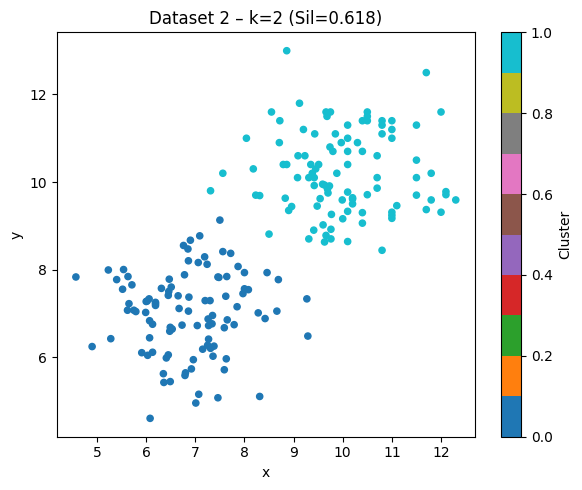

  k=3  |  Silhouette Score: 0.4253


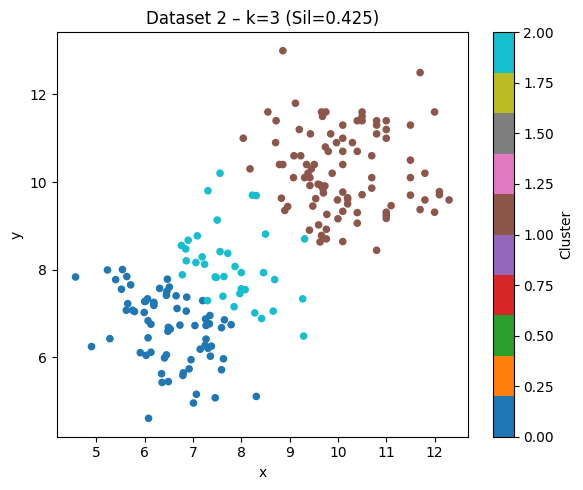

In [24]:
df2 = pd.read_csv("Dataset 2.csv", header=None, names=["x", "y"])

best_k2, scores2 = find_best_k(df2.values)
plot_silhouette_curve(scores2, "Dataset 2")

results2 = do_kmeans_and_save_results(df2, "Dataset2", best_k2)
for k, res in results2.items():
    print(f"  k={k}  |  Silhouette Score: {res['score']:.4f}")
    plot_clusters(df2, res["labels"], f"Dataset 2 – k={k} (Sil={res['score']:.3f})")

### Analysis
The dataset here is again, 2D points. Just as with dataset1, just looking at the raw data plotted, we see 2 obvious groups, though with a bit more noise and less obvious than in the first dataset. This is reflected in the reduced maximal silhouette score, 0.6178, a small decrease from data set 1. We again achieve the best silhouette at k=2, which confirms our visual suspicion. We again observe both an abitrary visual split at k=3 and a sharp decrease in silhouette score, 0.4253. We are starting to get into a bit of a weak area for k-means with the added noise. Though the data is still well-shaped, i.e. blobby and convex, for k-means.

## Dataset 3

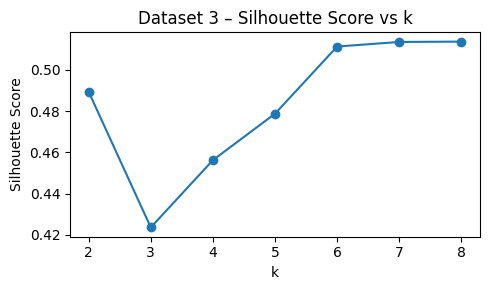

  k=7  |  Silhouette Score: 0.5135


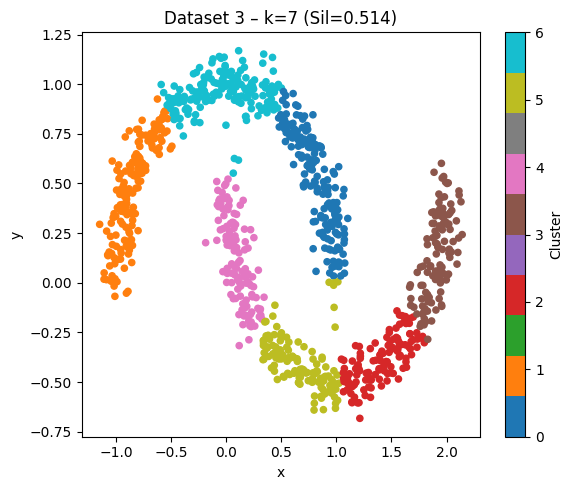

  k=8  |  Silhouette Score: 0.5137


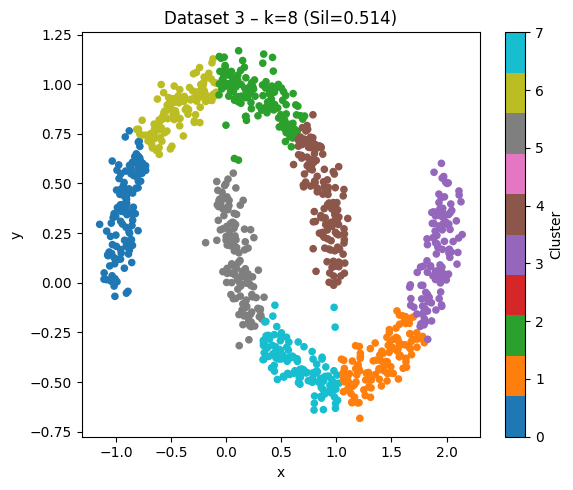

  k=9  |  Silhouette Score: 0.5141


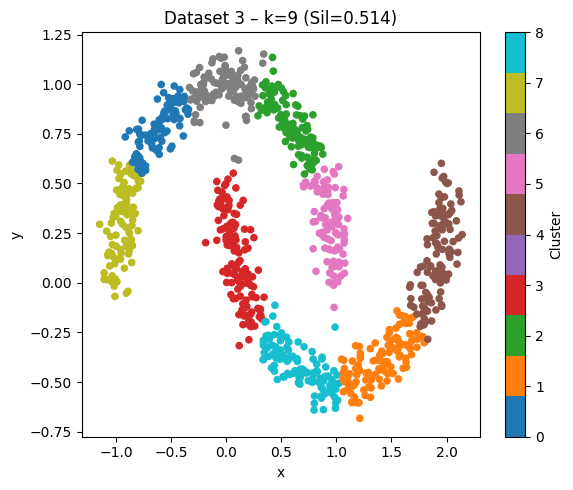

In [25]:
df3 = pd.read_csv("Dataset 3.csv", header=None, names=["x", "y"])

best_k3, scores3 = find_best_k(df3.values)
plot_silhouette_curve(scores3, "Dataset 3")

results3 = do_kmeans_and_save_results(df3, "Dataset3", best_k3)
for k, res in results3.items():
    print(f"  k={k}  |  Silhouette Score: {res['score']:.4f}")
    plot_clusters(df3, res["labels"], f"Dataset 3 – k={k} (Sil={res['score']:.3f})")

### Analysis
This data is again 2d points. But visually, we can observe 2 crescent shapes. Without even running we already know that k-means is not going to be able to identify these clusters, at least as we intuitively understand them. And of course looking at the clusters assigned by k-means, we can see that though they seem to be consistent, they don't capture the true pattern in the data. We can also observe that the top 3 k's (7,8,9) all have very similar silhouette scores 0.5135, 0.5137, 05141. This is a relatively low score, at least compared with the strong ones encountered on previous datasets. As well the fact that multiple top k's are scoring similarly suggests its struggling to find any true k. It seems that these k's primarily are chosen just because they are the ones able to break up the crescents into convex segments. Another clustering method would need to be used to really capture the higher level pattern that is visually obvious.

## 6. Dataset 4

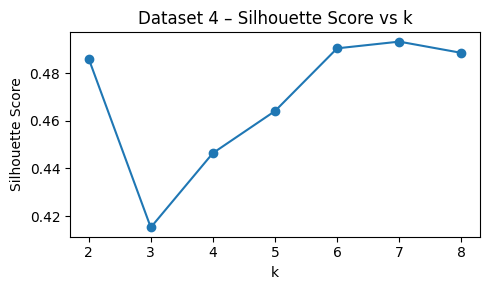

  k=6  |  Silhouette Score: 0.4904


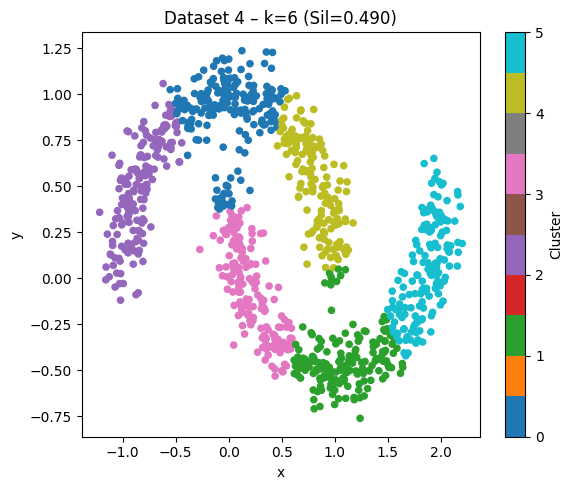

  k=7  |  Silhouette Score: 0.4932


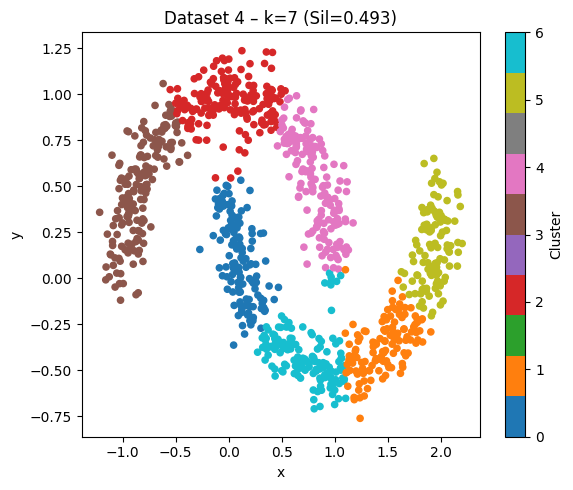

  k=8  |  Silhouette Score: 0.4885


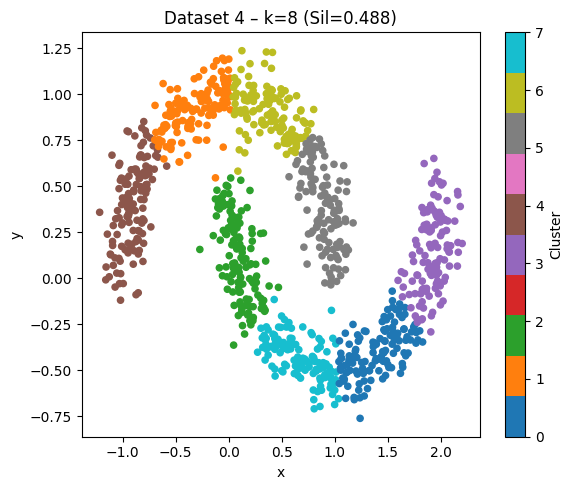

In [26]:
df4 = pd.read_csv("Dataset 4.csv", header=None, names=["x", "y"])

best_k4, scores4 = find_best_k(df4.values)
plot_silhouette_curve(scores4, "Dataset 4")

results4 = do_kmeans_and_save_results(df4, "Dataset4", best_k4)
for k, res in results4.items():
    print(f"  k={k}  |  Silhouette Score: {res['score']:.4f}")
    plot_clusters(df4, res["labels"], f"Dataset 4 – k={k} (Sil={res['score']:.3f})")

### Analysis
The data is again 2D points. Visually it resembles dataset 3, but with perhaps slightly more noise/spread. Most of the same observations we made on dataset 3 apply here again. We are not able to capture the true pattern because the true pattern is 2 concave crescents and not convex blobs which k-means is meant to capture. The 3 best k's are again 6,7, and 8. Again, they all scored very similarly 0.4904, 0.4932, and 0.4885 respectively. It is interesting to note that the scores aren't that much different than on dataset 3. I suppose since we aren't really capturing the true clusters, the noise isn't really affecting anything anyways, it might even be helping a bit by making everything a bit more 'blobby'.

## Dataset 5

Dataset 5: 400 points
Best k for Dataset 5: 4


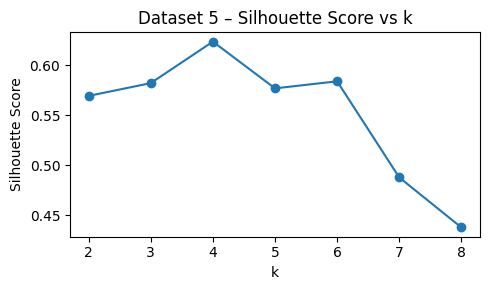

  k=3  |  Silhouette Score: 0.5821


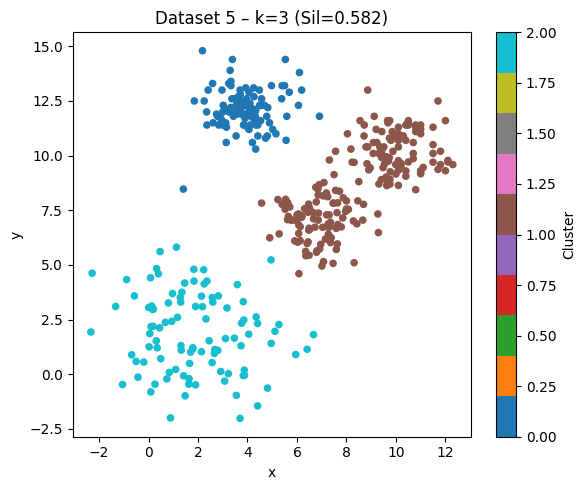

  k=4  |  Silhouette Score: 0.6235


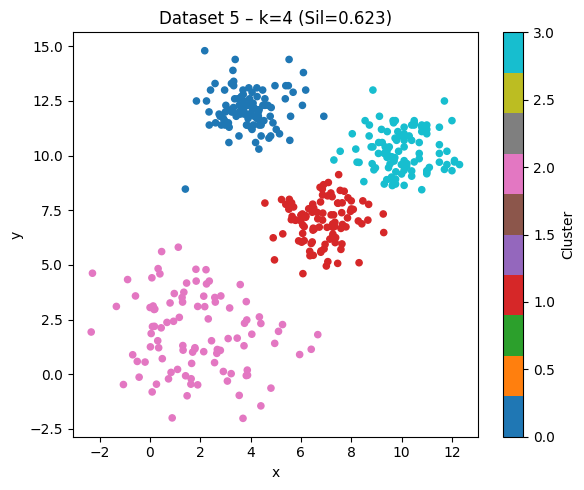

  k=5  |  Silhouette Score: 0.5768


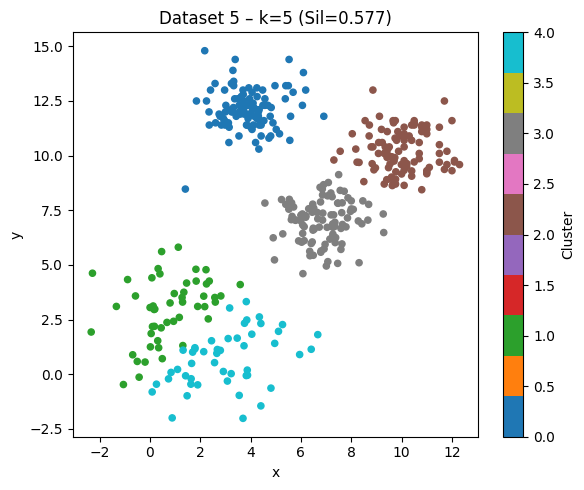

In [27]:
df5 = pd.read_csv("Dataset 5.csv", header=None, names=["x", "y"])
print(f"Dataset 5: {len(df5)} points")

best_k5, scores5 = find_best_k(df5.values)
print(f"Best k for Dataset 5: {best_k5}")
plot_silhouette_curve(scores5, "Dataset 5")

results5 = do_kmeans_and_save_results(df5, "Dataset5", best_k5)
for k, res in results5.items():
    print(f"  k={k}  |  Silhouette Score: {res['score']:.4f}")
    plot_clusters(df5, res["labels"], f"Dataset 5 – k={k} (Sil={res['score']:.3f})")

### Analysis
Dataset 5 is best represented with 4 clusters. Our silhouette plot shows that the silhouette scores for k between 2 and 6 are relatively high but the optimal is reached at k=4. The different clusters for k-1=3 can be seen in their respective plots.

## Dataset 6

Dataset 6: 200 points
Best k for Dataset 6: 2


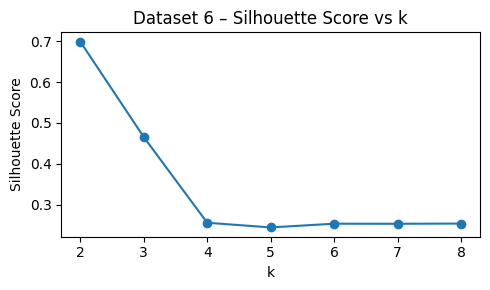

  k=2  |  Silhouette Score: 0.6989
  k=3  |  Silhouette Score: 0.4652


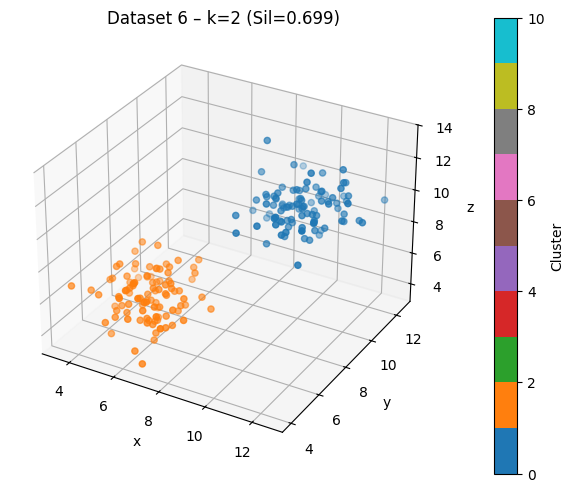

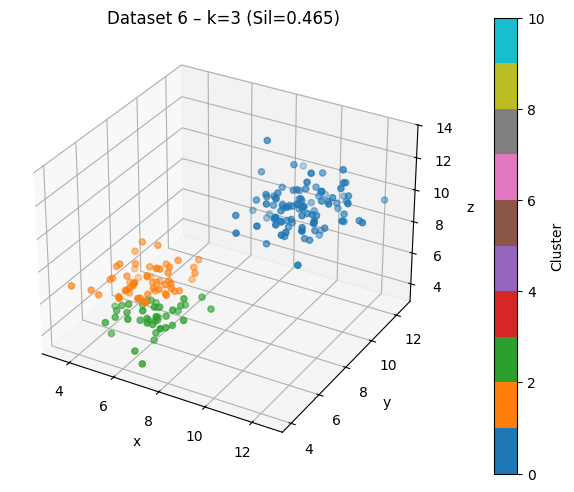

In [28]:
df6 = pd.read_csv("Dataset 6.csv", header=None, names=["x", "y", "z"])
print(f"Dataset 6: {len(df6)} points")

best_k6, scores6 = find_best_k(df6.values)
print(f"Best k for Dataset 6: {best_k6}")
plot_silhouette_curve(scores6, "Dataset 6")

results6 = do_kmeans_and_save_results(df6, "Dataset6", best_k6)
for k, res in results6.items():
    print(f"  k={k}  |  Silhouette Score: {res['score']:.4f}")
    plot_clusters_3d(df6, res["labels"], f"Dataset 6 – k={k} (Sil={res['score']:.3f})")

### Analysis
Dataset 6 is best represented with 2 clusters. Our silhouette plot shows that the silhouette score for k=2 is highest and everything greater than k=3 has a bad score. The different clusters for each k can be seen in their respective plots

## Dataset 7

Dataset 7: 200 points
Best k for Dataset 7: 2


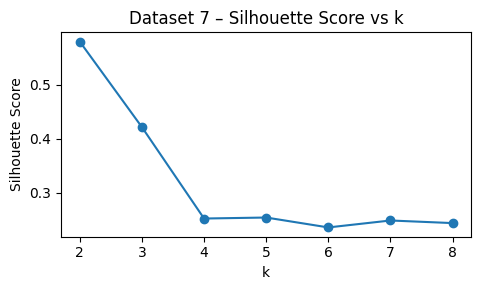

  k=2  |  Silhouette Score: 0.5796
  k=3  |  Silhouette Score: 0.4212


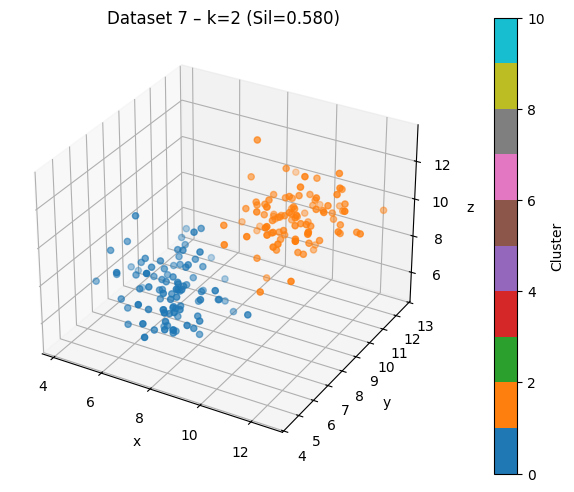

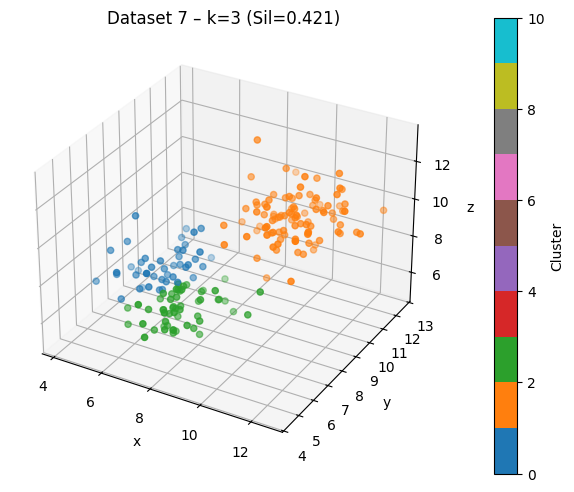

In [29]:
df7 = pd.read_csv("Dataset 7.csv", header=None, names=["x", "y", "z"])
print(f"Dataset 7: {len(df7)} points")

best_k7, scores7 = find_best_k(df7.values)
print(f"Best k for Dataset 7: {best_k7}")
plot_silhouette_curve(scores7, "Dataset 7")

results7 = do_kmeans_and_save_results(df7, "Dataset7", best_k7)
for k, res in results7.items():
    print(f"  k={k}  |  Silhouette Score: {res['score']:.4f}")
    plot_clusters_3d(df7, res["labels"], f"Dataset 7 – k={k} (Sil={res['score']:.3f})")

### Analysis
Dataset 7 is best represented with 2 clusters. Our silhouette plot shows that the silhouette score for k=2 is highest and everything greater than k=3 has a bad score. The different clusters can bee seen in their respective plots.
